# Entendendo a Distribuição Normal - Explicação Simples


**Analogia:** Imagine que você está observando as alturas dos jogadores de futebol no Brasil. A maioria tem altura "normal" (entre 1,70m e 1,80m), poucos são muito baixos (como o Romário com 1,67m) e poucos são muito altos (como o Felipão com 1,92m).

A **Distribuição Normal** é exatamente isso - a famosa "curva em sino" que aparece em quase tudo na natureza!

---

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

## PARTE 1: De Moedas para a Curva Mágica

### **Por que começar com moedas?**

O arquivo original começa jogando moedas porque é o **exemplo mais simples** para entender como chegamos na distribuição normal!

**Analogia do Pênalti:**
- 🥅 Jogo 1 pênalti = 1 moeda (acerta ou erra)
- 🥅 Jogo 10 pênaltis = 10 moedas (quantos acertos?)
- 🥅 Jogo 100 pênaltis = 100 moedas (padrão aparece!)

**A mágica:** Quanto mais pênaltis, mais o resultado se aproxima de uma **curva perfeita**!

In [3]:
# 🎯 EXEMPLO 1: Jogando 1 pênalti (1 moeda)
penalti_simples = np.random.binomial(1, 0.5)  # 0 = errou, 1 = acertou
print(f"🥅 Resultado do pênalti: {'⚽ GOOOL!' if penalti_simples else '❌ Defendeu!'}")

# 🎯 EXEMPLO 2: Série de 10 pênaltis
serie_penaltis = np.random.binomial(1, 0.5, 10)
gols = serie_penaltis.sum()
print(f"⚽ Em 10 pênaltis, fez {gols} gols")
print(f"📊 Sequência: {serie_penaltis}")

🥅 Resultado do pênalti: ⚽ GOOOL!
⚽ Em 10 pênaltis, fez 2 gols
📊 Sequência: [1 0 0 0 0 1 0 0 0 0]


### 📈 **O Segredo: Aumentando o Número de Tentativas**

**No código original:** Vai de 1 moeda → 2 moedas → 100 moedas

**Na nossa analogia:** 
- 🥅 **1 pênalti:** Resultado aleatório total
- 🥅 **10 pênaltis:** Começa a ver padrão
- 🥅 **100 pênaltis:** Padrão fica claro
- 🥅 **1000+ pênaltis:** CURVA PERFEITA aparece!

C:\Users\gusgo\AppData\Local\Temp\ipykernel_23804\4290698080.py:25: UserWarning: Glyph 129349 (\N{GOAL NET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


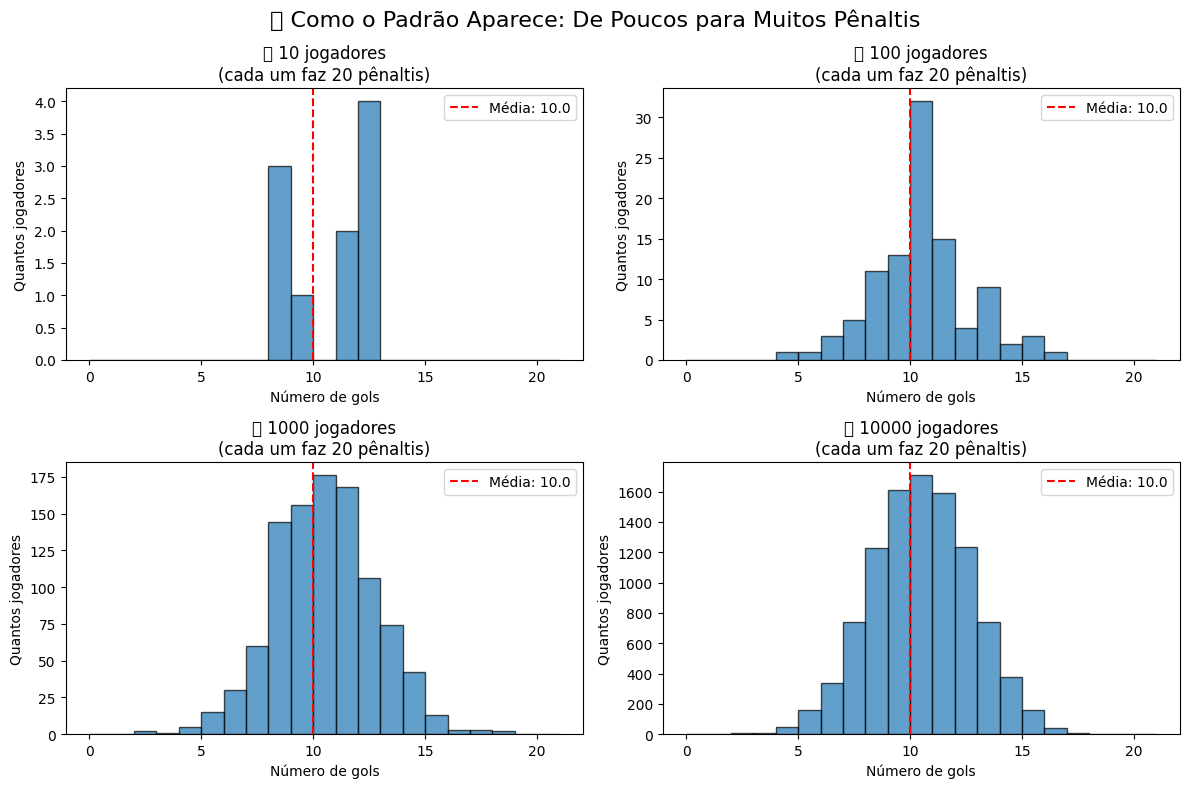

🎯 OBSERVE: Conforme aumenta o número de jogadores, a forma fica mais 'lisa' e parecida com sino!


In [12]:
# 🎯 DEMONSTRAÇÃO: Evolução do Padrão
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('🥅 Como o Padrão Aparece: De Poucos para Muitos Pênaltis', fontsize=16)

# Diferentes números de "jogadores" fazendo pênaltis
tentativas = [10, 100, 1000, 10000]
n_penaltis = 20  # Cada jogador faz 20 pênaltis

for i, num_jogadores in enumerate(tentativas):
    # Simular resultados
    resultados = np.random.binomial(n_penaltis, 0.5, num_jogadores)
    
    # Plotar
    ax = axes[i//2, i%2]
    ax.hist(resultados, bins=range(0, n_penaltis+2), alpha=0.7, edgecolor='black')
    ax.set_title(f'🥅 {num_jogadores} jogadores\n(cada um faz {n_penaltis} pênaltis)')
    ax.set_xlabel('Número de gols')
    ax.set_ylabel('Quantos jogadores')
    
    # Adicionar linha da média
    media = n_penaltis * 0.5
    ax.axvline(media, color='red', linestyle='--', label=f'Média: {media}')
    ax.legend()

plt.tight_layout()
plt.show()

print("🎯 OBSERVE: Conforme aumenta o número de jogadores, a forma fica mais 'lisa' e parecida com sino!")

## 🧮 PARTE 2: A Fórmula Mágica da Curva Normal

### 📐 **A Equação que Governa o Mundo:**

$ f(x) = \frac{1}{\sqrt{2 \pi \sigma^2}} e^{-\frac{(x - \mu)^2}{2 \sigma^2}} $

**"Cara, que fórmula doida é essa?"** 🤯

Calma! Vou explicar cada pedacinho:

**Analogia da Curva de Aproveitamento:**
- 🎯 **μ (mu)**: A média dos gols - onde a maioria dos jogadores acerta
- 🎯 **σ (sigma)**: O "espalhamento" - quão diferentes são os jogadores
- 🎯 **e e π**: Constantes matemáticas que fazem a mágica funcionar
- 🎯 **Resultado**: A altura da curva em cada ponto

**Traduzindo:** "Me diga onde está a média e o quanto os dados se espalham, que eu te desenho a curva perfeita!"

In [13]:
# 🎯 IMPLEMENTAÇÃO DA FÓRMULA MÁGICA
def curva_normal(x, media=0.0, desvio=1.0):
    """
    🧮 A fórmula da distribuição normal explicada:
    
    Parâmetros:
    - x: onde queremos calcular a altura da curva
    - media: onde está o "centro" dos dados
    - desvio: o quanto os dados se "espalham"
    """
    # 🔢 Constante de normalização (garante que a área sob a curva = 1)
    normalizacao = 1.0 / np.sqrt(2.0 * np.pi * desvio**2)
    
    # 📐 O "coração" da fórmula - exponencial negativa
    exponencial = np.exp(-(x - media)**2 / (2.0 * desvio**2))
    
    # ✨ Resultado final
    return normalizacao * exponencial

# 🧪 Testando a função
print(f"🎯 Altura da curva no centro (x=0): {curva_normal(0.0):.4f}")
print(f"🎯 Altura da curva em x=1: {curva_normal(1.0):.4f}")
print(f"🎯 Altura da curva em x=2: {curva_normal(2.0):.4f}")
print("📊 Note como vai diminuindo conforme se afasta do centro!")

🎯 Altura da curva no centro (x=0): 0.3989
🎯 Altura da curva em x=1: 0.2420
🎯 Altura da curva em x=2: 0.0540
📊 Note como vai diminuindo conforme se afasta do centro!


C:\Users\gusgo\AppData\Local\Temp\ipykernel_23804\4266562023.py:34: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\gusgo\AppData\Local\Temp\ipykernel_23804\4266562023.py:34: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\gusgo\AppData\Local\Temp\ipykernel_23804\4266562023.py:34: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


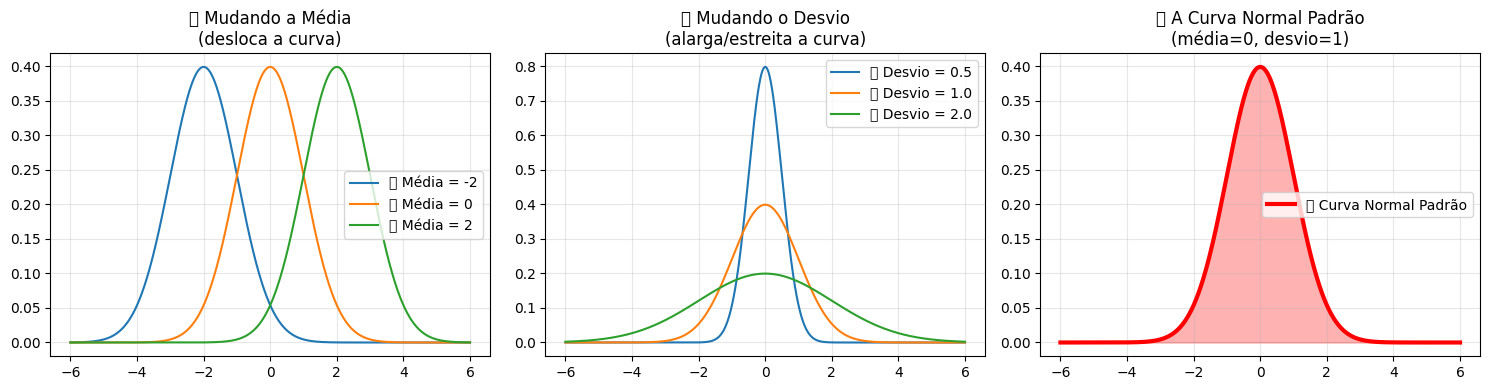

🎯 LIÇÕES:
• Média: desloca a curva para direita/esquerda
• Desvio: faz a curva ficar mais larga (desvio alto) ou estreita (desvio baixo)
• Forma de sino: sempre igual, só muda posição e largura!


In [14]:
# 🎨 VISUALIZANDO DIFERENTES CURVAS NORMAIS
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Range de valores x
x = np.linspace(-6, 6, 1000)

# 📊 Gráfico 1: Diferentes médias
ax = axes[0]
for media in [-2, 0, 2]:
    y = curva_normal(x, media=media, desvio=1)
    ax.plot(x, y, label=f'🎯 Média = {media}')
ax.set_title('🎯 Mudando a Média\n(desloca a curva)')
ax.legend()
ax.grid(True, alpha=0.3)

# 📊 Gráfico 2: Diferentes desvios
ax = axes[1]
for desvio in [0.5, 1.0, 2.0]:
    y = curva_normal(x, media=0, desvio=desvio)
    ax.plot(x, y, label=f'📏 Desvio = {desvio}')
ax.set_title('📏 Mudando o Desvio\n(alarga/estreita a curva)')
ax.legend()
ax.grid(True, alpha=0.3)

# 📊 Gráfico 3: A curva "padrão"
ax = axes[2]
y = curva_normal(x, media=0, desvio=1)
ax.plot(x, y, 'red', linewidth=3, label='🌟 Curva Normal Padrão')
ax.fill_between(x, y, alpha=0.3, color='red')
ax.set_title('🌟 A Curva Normal Padrão\n(média=0, desvio=1)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("🎯 LIÇÕES:")
print("• Média: desloca a curva para direita/esquerda")
print("• Desvio: faz a curva ficar mais larga (desvio alto) ou estreita (desvio baixo)")
print("• Forma de sino: sempre igual, só muda posição e largura!")

## 🔬 PARTE 3: Testando se os Dados são "Normais"

### 🕵️ **Por que isso importa?**

**Analogia do Técnico de Futebol:**
- 🏃‍♂️ Você tem dados das velocidades dos seus jogadores
- 🤔 Quer saber se seguem distribuição normal
- ✅ Se sim: pode usar estatísticas "normais" para analisar
- ❌ Se não: precisa de métodos especiais

**Ferramentas de Detetive:**
1. 📊 **Histograma**: "Tem cara de sino?"
2. 📈 **Q-Q Plot**: "Os pontos ficam em linha reta?"
3. 🧪 **Teste Shapiro-Wilk**: "Matematicamente, é normal?"

In [15]:
# 🧪 GERANDO DADOS PARA TESTAR
print("🎲 Vamos gerar alguns dados para testar...")

# Dados que SÃO normais (gerados da distribuição normal)
dados_normais = np.random.normal(loc=0, scale=1, size=1000)

# Dados que NÃO são normais (distribuição uniforme)
dados_nao_normais = np.random.uniform(low=-3, high=3, size=1000)

print(f"✅ Gerados {len(dados_normais)} dados normais")
print(f"❌ Gerados {len(dados_nao_normais)} dados não-normais")
print("🔍 Agora vamos investigar cada um!")

🎲 Vamos gerar alguns dados para testar...
✅ Gerados 1000 dados normais
❌ Gerados 1000 dados não-normais
🔍 Agora vamos investigar cada um!


C:\Users\gusgo\AppData\Local\Temp\ipykernel_23804\232194061.py:28: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\gusgo\AppData\Local\Temp\ipykernel_23804\232194061.py:28: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\gusgo\AppData\Local\Temp\ipykernel_23804\232194061.py:28: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


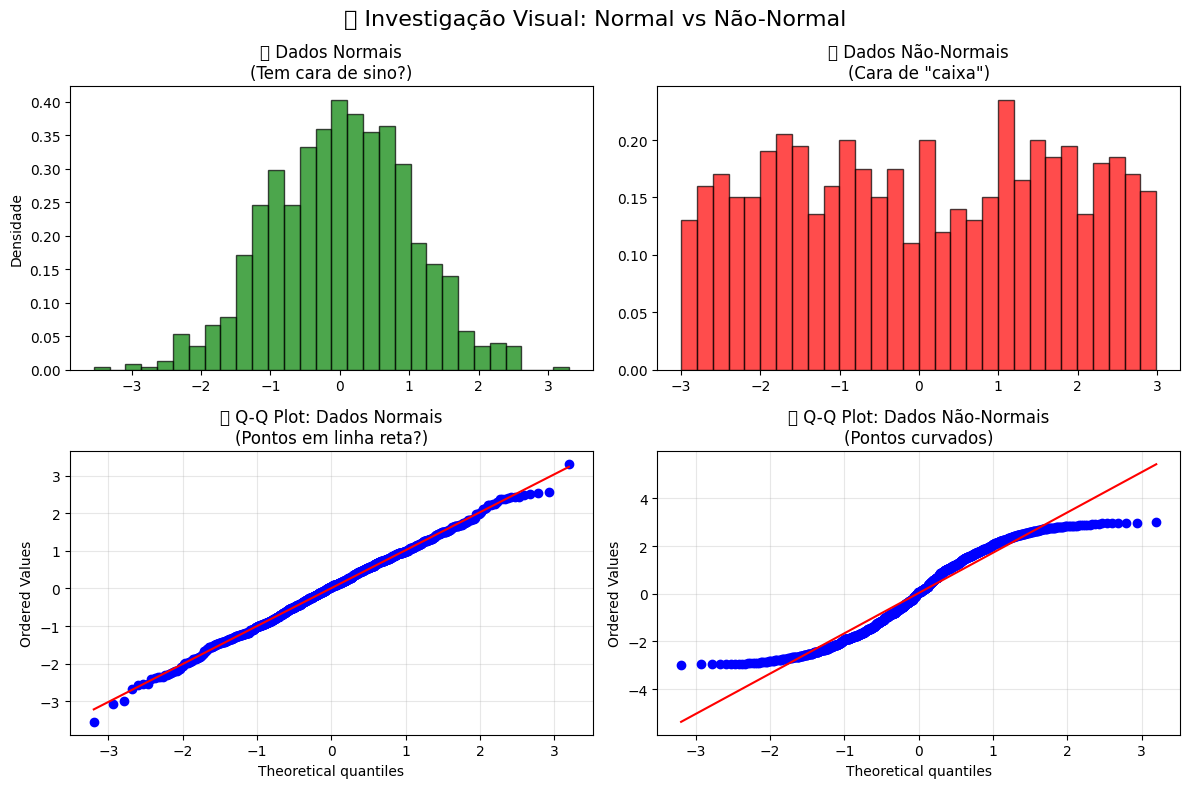

🎯 COMO INTERPRETAR:
📊 Histograma: Dados normais = formato sino | Não-normais = formato irregular
📈 Q-Q Plot: Normal = pontos na linha reta | Não-normal = pontos curvados


In [16]:
# 🔍 TESTE 1: INSPEÇÃO VISUAL - HISTOGRAMA
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('🔍 Investigação Visual: Normal vs Não-Normal', fontsize=16)

# Dados normais - Histograma
ax = axes[0, 0]
ax.hist(dados_normais, bins=30, density=True, alpha=0.7, edgecolor='black', color='green')
ax.set_title('✅ Dados Normais\n(Tem cara de sino?)')
ax.set_ylabel('Densidade')

# Dados não-normais - Histograma
ax = axes[0, 1]
ax.hist(dados_nao_normais, bins=30, density=True, alpha=0.7, edgecolor='black', color='red')
ax.set_title('❌ Dados Não-Normais\n(Cara de "caixa")')

# Dados normais - Q-Q Plot
ax = axes[1, 0]
stats.probplot(dados_normais, dist='norm', plot=ax)
ax.set_title('✅ Q-Q Plot: Dados Normais\n(Pontos em linha reta?)')
ax.grid(True, alpha=0.3)

# Dados não-normais - Q-Q Plot
ax = axes[1, 1]
stats.probplot(dados_nao_normais, dist='norm', plot=ax)
ax.set_title('❌ Q-Q Plot: Dados Não-Normais\n(Pontos curvados)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("🎯 COMO INTERPRETAR:")
print("📊 Histograma: Dados normais = formato sino | Não-normais = formato irregular")
print("📈 Q-Q Plot: Normal = pontos na linha reta | Não-normal = pontos curvados")

In [17]:
# 🧪 TESTE 2: SHAPIRO-WILK - O TESTE MATEMÁTICO
print("🧪 TESTE SHAPIRO-WILK - O Detetive Matemático")
print("="*50)

# Teste nos dados normais
stat_normal, p_normal = stats.shapiro(dados_normais)
print(f"✅ DADOS NORMAIS:")
print(f"   📊 Estatística: {stat_normal:.4f}")
print(f"   🎯 P-valor: {p_normal:.6f}")
print(f"   🔍 Conclusão: {'✅ SÃO normais!' if p_normal > 0.05 else '❌ NÃO são normais!'}")

print()

# Teste nos dados não-normais
stat_nao_normal, p_nao_normal = stats.shapiro(dados_nao_normais)
print(f"❌ DADOS NÃO-NORMAIS:")
print(f"   📊 Estatística: {stat_nao_normal:.4f}")
print(f"   🎯 P-valor: {p_nao_normal:.10f}")
print(f"   🔍 Conclusão: {'✅ SÃO normais!' if p_nao_normal > 0.05 else '❌ NÃO são normais!'}")

print("\n" + "="*50)
print("🎓 COMO INTERPRETAR O TESTE:")
print("• P-valor > 0.05 → Dados SÃO normais (não rejeitamos H0)")
print("• P-valor ≤ 0.05 → Dados NÃO são normais (rejeitamos H0)")
print("• H0 = 'os dados seguem distribuição normal'")

🧪 TESTE SHAPIRO-WILK - O Detetive Matemático
✅ DADOS NORMAIS:
   📊 Estatística: 0.9985
   🎯 P-valor: 0.533120
   🔍 Conclusão: ✅ SÃO normais!

❌ DADOS NÃO-NORMAIS:
   📊 Estatística: 0.9511
   🎯 P-valor: 0.0000000000
   🔍 Conclusão: ❌ NÃO são normais!

🎓 COMO INTERPRETAR O TESTE:
• P-valor > 0.05 → Dados SÃO normais (não rejeitamos H0)
• P-valor ≤ 0.05 → Dados NÃO são normais (rejeitamos H0)
• H0 = 'os dados seguem distribuição normal'


## 📐 PARTE 4: A Área Sob a Curva - Probabilidades

### 🎯 **Por que a área importa?**

**Analogia da Arquibancada:**
- 🏟️ A curva normal é como a arquibancada de um estádio
- 👥 A "área" representa quantas pessoas estão em cada seção
- 📊 Área total = 100% dos torcedores
- 🎯 Área entre dois pontos = % de torcedores naquela seção

**Regra dos 68-95-99.7:**
- 📊 68% dos dados estão a 1 desvio da média
- 📊 95% dos dados estão a 2 desvios da média  
- 📊 99.7% dos dados estão a 3 desvios da média

**Traduzindo:** "Se você sabe a média e o desvio, pode prever onde estão 95% dos seus dados!"

C:\Users\gusgo\AppData\Local\Temp\ipykernel_23804\682035389.py:37: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


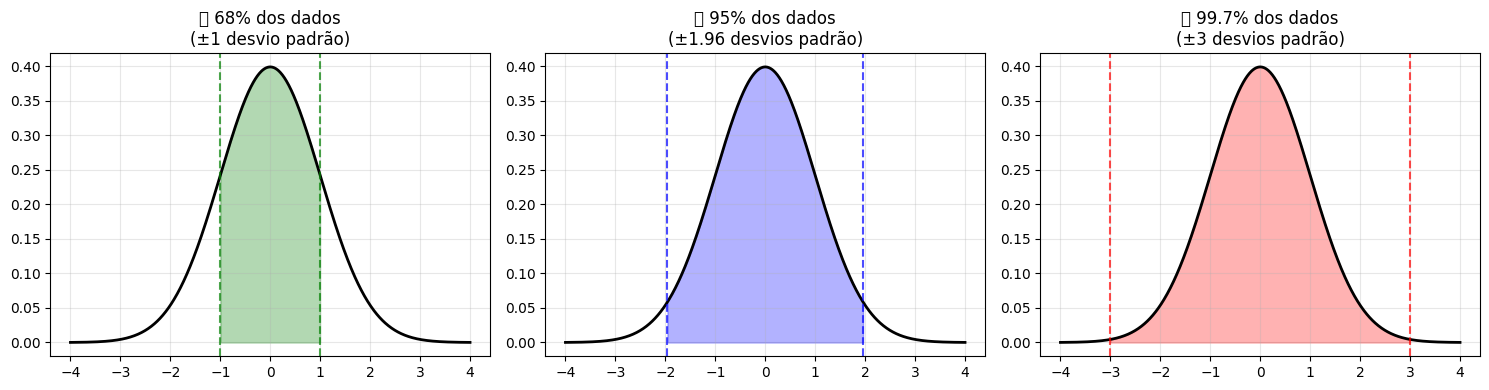

🎯 APLICAÇÃO PRÁTICA:
🏃‍♂️ Se a velocidade média dos jogadores é 25 km/h com desvio de 3 km/h:
   • 68% correm entre 22 e 28 km/h
   • 95% correm entre 19.1 e 30.9 km/h
   • 99.7% correm entre 16 e 34 km/h


In [18]:
# 🎨 VISUALIZANDO AS ÁREAS IMPORTANTES
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x)  # Usando a função pronta do scipy

# 📊 Gráfico 1: Regra 68%
ax = axes[0]
ax.plot(x, y, 'black', linewidth=2)
mask_68 = (x >= -1) & (x <= 1)
ax.fill_between(x, y, where=mask_68, alpha=0.3, color='green')
ax.set_title('📊 68% dos dados\n(±1 desvio padrão)')
ax.axvline(-1, color='green', linestyle='--', alpha=0.7)
ax.axvline(1, color='green', linestyle='--', alpha=0.7)
ax.grid(True, alpha=0.3)

# 📊 Gráfico 2: Regra 95%
ax = axes[1]
ax.plot(x, y, 'black', linewidth=2)
mask_95 = (x >= -1.96) & (x <= 1.96)
ax.fill_between(x, y, where=mask_95, alpha=0.3, color='blue')
ax.set_title('📊 95% dos dados\n(±1.96 desvios padrão)')
ax.axvline(-1.96, color='blue', linestyle='--', alpha=0.7)
ax.axvline(1.96, color='blue', linestyle='--', alpha=0.7)
ax.grid(True, alpha=0.3)

# 📊 Gráfico 3: Regra 99.7%
ax = axes[2]
ax.plot(x, y, 'black', linewidth=2)
mask_997 = (x >= -3) & (x <= 3)
ax.fill_between(x, y, where=mask_997, alpha=0.3, color='red')
ax.set_title('📊 99.7% dos dados\n(±3 desvios padrão)')
ax.axvline(-3, color='red', linestyle='--', alpha=0.7)
ax.axvline(3, color='red', linestyle='--', alpha=0.7)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("🎯 APLICAÇÃO PRÁTICA:")
print("🏃‍♂️ Se a velocidade média dos jogadores é 25 km/h com desvio de 3 km/h:")
print(f"   • 68% correm entre {25-3} e {25+3} km/h")
print(f"   • 95% correm entre {25-1.96*3:.1f} e {25+1.96*3:.1f} km/h")
print(f"   • 99.7% correm entre {25-3*3} e {25+3*3} km/h")

In [19]:
# 🎯 EXEMPLO PRÁTICO: CALCULANDO PROBABILIDADES
print("🧮 CALCULADORA DE PROBABILIDADES - DISTRIBUIÇÃO NORMAL")
print("="*60)

# Parâmetros do exemplo
media = 175  # altura média em cm
desvio = 10  # desvio padrão em cm

print(f"📏 Exemplo: Altura dos jogadores (média={media}cm, desvio={desvio}cm)")
print()

# Probabilidade de ser mais alto que 180cm
prob_alto = 1 - stats.norm.cdf(180, loc=media, scale=desvio)
print(f"🏀 P(altura > 180cm) = {prob_alto:.1%}")

# Probabilidade de estar entre 165 e 185cm
prob_entre = stats.norm.cdf(185, loc=media, scale=desvio) - stats.norm.cdf(165, loc=media, scale=desvio)
print(f"📊 P(165cm < altura < 185cm) = {prob_entre:.1%}")

# Encontrar a altura que 90% dos jogadores estão abaixo
altura_90 = stats.norm.ppf(0.90, loc=media, scale=desvio)
print(f"📈 90% dos jogadores têm menos que {altura_90:.1f}cm")

print()
print("💡 FUNÇÕES ÚTEIS:")
print("• stats.norm.cdf(x) → área à esquerda de x (probabilidade cumulativa)")
print("• stats.norm.ppf(p) → valor x onde p% dos dados estão abaixo (percentil)")
print("• 1 - cdf(x) → área à direita de x")
print("• cdf(b) - cdf(a) → área entre a e b")

🧮 CALCULADORA DE PROBABILIDADES - DISTRIBUIÇÃO NORMAL
📏 Exemplo: Altura dos jogadores (média=175cm, desvio=10cm)

🏀 P(altura > 180cm) = 30.9%
📊 P(165cm < altura < 185cm) = 68.3%
📈 90% dos jogadores têm menos que 187.8cm

💡 FUNÇÕES ÚTEIS:
• stats.norm.cdf(x) → área à esquerda de x (probabilidade cumulativa)
• stats.norm.ppf(p) → valor x onde p% dos dados estão abaixo (percentil)
• 1 - cdf(x) → área à direita de x
• cdf(b) - cdf(a) → área entre a e b


## 🎓 RESUMO: O que Aprendemos sobre Distribuição Normal

### 🧠 **Conceitos Principais:**

1. **🎲 Das Moedas à Curva:**
   - Jogando muitas moedas → padrão aparece
   - Padrão = distribuição normal (curva sino)
   - Quanto mais dados, mais perfeita a curva

2. **📐 A Fórmula Mágica:**
   - μ (média): onde está o centro
   - σ (desvio): quanto os dados se espalham
   - Fórmula: calcula altura da curva em qualquer ponto

3. **🔍 Detectando Normalidade:**
   - **Visual**: Histograma (sino?) + Q-Q plot (linha reta?)
   - **Matemático**: Teste Shapiro-Wilk (p > 0.05?)

4. **📊 Áreas = Probabilidades:**
   - 68% dentro de ±1σ
   - 95% dentro de ±2σ (mais precisamente ±1.96σ)
   - 99.7% dentro de ±3σ

### 🚀 **Por que isso é IMPORTANTE?**

**A distribuição normal está em TUDO:**
- 📏 Alturas e pesos de pessoas
- 🧠 Notas de provas (quando bem feitas)
- 💰 Flutuações de preços
- 🌡️ Variações de temperatura
- ⚽ Performance de atletas
- 🔬 Erros de medição

**Sabendo isso, você pode:**
- ✅ Prever probabilidades
- ✅ Detectar valores anômalos (outliers)
- ✅ Fazer inferências estatísticas
- ✅ Criar intervalos de confiança
- ✅ Entender como a natureza funciona!

---

### 🎯 **Próximos Passos:**

Agora que você entende a distribuição normal, pode:
1. 📊 Analisar seus próprios dados
2. 🧪 Fazer testes de hipóteses
3. 📈 Criar modelos estatísticos
4. 🔮 Fazer previsões baseadas em dados

**A estatística é a arte de extrair conhecimento dos dados - e a distribuição normal é sua ferramenta mais poderosa!** 🌟